<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/NLP/Encoding/Bag_of_Words_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing Libraries

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Importing Dataset

In [147]:
# Read tsv using delimiter = '\t'
# Ignore all the quotes in the text usng quoting = 3
df = pd.read_csv("/content/Restaurant_Reviews.tsv", delimiter = '\t', quoting = 3)

##Cleaning the Dataset
Remove punctuation and convert to lowercase

In [148]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [149]:
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

corpus = []

for i in range(0, len(df)):
  review = re.sub('[^a-zA-Z]', ' ', df['Review'][i])                              # Remove all punctuation marks and replace them with space
  review = review.lower()                                                         # Convert to lowercase
  review = review.split()                                                         # Split into list of words

  all_stopwords = stopwords.words('english')
  all_stopwords.remove('not')                                                     # Remove "not" from stopwords

  porter_stemmer = PorterStemmer()
  review = [porter_stemmer.stem(word)
            for word in review
            if word not in set(all_stopwords)
            ]
  review = ' '.join(review)

  corpus .append(review)

In [150]:
print(corpus)

['wow love place', 'crust not good', 'not tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch', 'servic prompt', 'would not go back', 'cashier care ever say still end wayyy overpr', 'tri cape cod ravoli chicken cranberri mmmm', 'disgust pretti sure human hair', 'shock sign indic cash', 'highli recommend', 'waitress littl slow servic', 'place not worth time let alon vega', 'not like', 'burritto blah', 'food amaz', 'servic also cute', 'could care less interior beauti', 'perform', 'right red velvet cake ohhh stuff good', 'never brought salad ask', 'hole wall great mexican street taco friendli staff', 'took hour get food tabl restaur food luke warm sever run around like total overwhelm', 'worst salmon sashimi', 'also combo like burger fri beer decent deal', 'like final blow', 'found place accid could not

##Creating the Bag of Words model:
###Tokenization and Feature Extraction

In [151]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features = 1500)
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:, -1].values

##Splitting the dataset into the training set and test set

In [152]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

##Training the Classification model on training set

In [153]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)

classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

##Predicting the test set results

In [154]:
y_predicted = classifier.predict(X_test)

y_pred_vector = y_predicted.reshape(len(y_predicted), 1)
y_test_vector = y_test.reshape(len(y_test), 1)

np.concatenate((y_pred_vector, y_test_vector), axis = 1)

array([[0, 0],
       [1, 1],
       [1, 0],
       [0, 0],
       [1, 1],
       [1, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 1],
       [0, 1],
       [1, 1],
       [0, 1],
       [0, 0],
       [0, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 1],
       [1, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 0],
       [1, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [1,

##Confusion Matrix

Confusion Matrix: 
 [[78 17]
 [23 82]]

Accuracy Score: 
0.8


<Axes: >

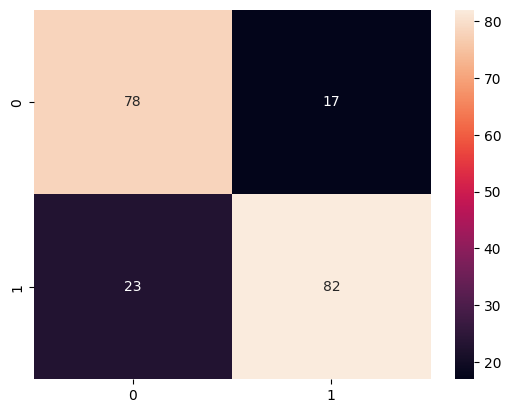

In [155]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test_vector, y_pred_vector)
print("Confusion Matrix: \n", cm)
print("\nAccuracy Score: ")
print(accuracy_score(y_test_vector, y_pred_vector))

import seaborn as sns
sns.heatmap(cm, annot = True)